# Week 8 Live Session: Computer Vision with Convolutional Neural Networks

## What you'll do today

1. **Recap Week 7's MLP** on Fashion-MNIST — establish the baseline (~88% accuracy)
2. **Build a CNN** using Keras Conv2D and MaxPooling2D layers
3. **Beat the MLP baseline** at the *same* parameter budget
4. **Visualize what the CNN learned** — see filters and feature maps
5. **Pair programming**: try architecture variants in the next notebook

## Continuity from Week 7
Last week you used `keras.Sequential` with `Dense` and `Dropout`, applied `EarlyStopping`, and saved models with `model.save()`. **Today you'll use the same patterns** — `compile()`, `fit()`, callbacks — but with new layer types built for spatial data.

## Foreshadow for Week 9
Today you'll train CNNs from scratch on 60,000 labeled images. **Next week's question:** what if you only have 200 images? That's transfer learning.

## Section 0: Setup and GPU verification

**Run this cell first.** It verifies you have a GPU available. If not, the notebook will still work but training will be slower.

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'  # PyTorch backend, same as Weeks 6-7

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split as test_train_split

keras.utils.set_random_seed(42)

# GPU verification
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    print(f'GPU available: {device_name}')
elif torch.backends.mps.is_available():
    print('Apple Silicon MPS available')
else:
    print('No GPU detected — training will be slower but will still work')

print(f'Keras version: {keras.__version__}')
print(f'Backend: {keras.backend.backend()}')

Apple Silicon MPS available
Keras version: 3.13.2
Backend: torch


## Section 1: Load Fashion-MNIST (familiar from Week 7)

Same data we used last week. The difference today is how we'll process it.

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


print(f'Training set: {X_train_full.shape}, labels: {y_train_full.shape}')
print(f'Test set: {X_test.shape}, labels: {y_test.shape}')
print(f'Pixel range: [{X_train_full.min()}, {X_train_full.max()}]')

Training set: (60000, 28, 28), labels: (60000,)
Test set: (10000, 28, 28), labels: (10000,)
Pixel range: [0, 255]


### The critical difference from Week 7: the channel dimension

Last week we **flattened** images: `X.reshape(-1, 784)`. 

This week we **preserve spatial structure** and **add a channel dimension**: `(28, 28)` → `(28, 28, 1)`.

Why? `Conv2D` expects 4D input: `(batch, height, width, channels)`. For grayscale, channels=1; for RGB, channels=3.

In [3]:
# Normalize to [0, 1] (same as Week 7)
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train, X_val, y_train, y_val = test_train_split(X_train_full, y_train_full, test_size=0.2, random_state=42)


# Add channel dimension — this is the key shape change for CNNs
X_train = np.expand_dims(X_train, axis=-1)  # (48000, 28, 28) -> (60000, 28, 28, 1)
X_test = np.expand_dims(X_test, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

print(f'After preprocessing: {X_train.shape}')  # (48000, 28, 28, 1)
print('The trailing 1 is the channel dimension — required for Conv2D')

After preprocessing: (48000, 28, 28, 1)
The trailing 1 is the channel dimension — required for Conv2D


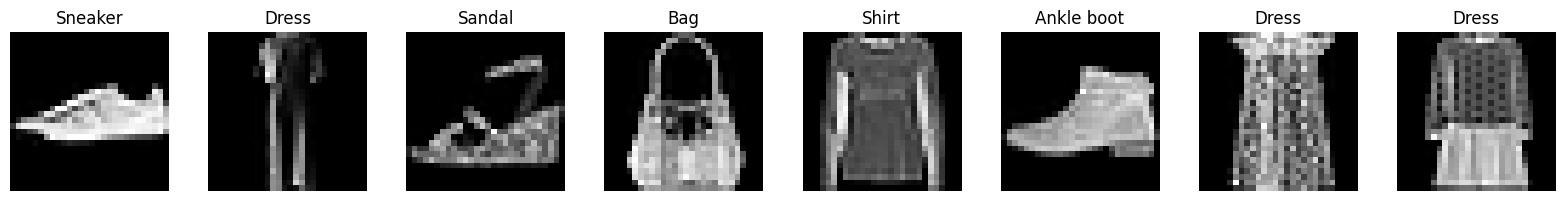

In [4]:
# Visual sanity check — show 8 sample images with labels
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Section 2: Recap — train a Week 7 MLP for comparison

We'll establish the baseline. This is exactly the architecture from Week 7.

In [5]:
# Flatten for MLP (Week 7 approach)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)
X_val_flat = X_val.reshape(-1, 784)

mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='Week7_MLP')
mlp.summary()

Model: "Week7_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

In [7]:
mlp_history = mlp.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

mlp_test_loss, mlp_test_acc = mlp.evaluate(X_test_flat, y_test, verbose=0)
print(f'\nMLP test accuracy: {mlp_test_acc:.4f}')

Epoch 1/20


  1/375 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.1641 - loss: 2.3581

  8/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2094 - loss: 2.2085   

 16/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2625 - loss: 2.0832

 24/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3042 - loss: 1.9774

...

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8932 - loss: 0.2868

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8931 - loss: 0.2869

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8931 - loss: 0.2871

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8915 - loss: 0.2954 - val_accuracy: 0.8873 - val_loss: 0.3136



MLP test accuracy: 0.8800


**Note the MLP parameter count from `model.summary()`** — **109,386** parameters (~109K). We'll match this budget with the CNN below.

Expected result: ~88% test accuracy. This is our baseline.

## Section 3: Build a CNN

### Architecture pattern
```
Input (28, 28, 1)
  → Conv2D(32 filters, 3×3) + ReLU
  → MaxPooling2D(2×2)        # halves spatial dimensions
  → Conv2D(32 filters, 3×3) + ReLU
  → MaxPooling2D(2×2)
  → Flatten                   # convert spatial output to flat vector
  → Dense(64) + ReLU
  → Dropout(0.3)
  → Dense(10) + Softmax
```

### Mental model
- **Conv2D** = sliding pattern detector (32 different small filters scanning the image)
- **MaxPooling2D** = downsample by taking the max in each 2×2 region ("don't care WHERE, care WHETHER")
- **Flatten** = convert the final spatial feature map into a flat vector for the classifier head
- **Dense + Softmax** = the same classifier head you used in Week 7

In [8]:
cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='Week8_CNN')

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "Week8_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,634 (432.16 KB)

 Trainable params: 110,634 (432.16 KB)

 Non-trainable params: 0 (0.00 B)

### Look at the parameter count

**Compare:**
- MLP: **109,386** parameters (~109K)
- CNN: **110,634** parameters (~111K) — essentially the *same* budget (within ~1%)

This is a deliberate, apples-to-apples comparison: **same parameter budget, very different architecture.** When the CNN wins, it is NOT because it is bigger.

But notice **where** the parameters live:
- In the MLP, almost all parameters are in the first `Dense(128)` layer wired to the 784-pixel input (784 × 128 ≈ 100K weights) — and every weight sees just one pixel.
- In the CNN, the two conv layers — the part that actually *sees* the image — cost only **9,568** parameters total (first conv: 32 filters × 3 × 3 = 288 weights + 32 biases = 320). The bulk sits in the `Dense(64)` after `Flatten`.

**Parameter sharing** is what makes conv layers efficient. The same 9-weight filter is applied at every spatial position. The filter doesn't care WHERE in the image; it cares WHAT pattern. Same budget as the MLP — spent far more wisely.

In [9]:
# Train the CNN with EarlyStopping (same callback you used in Week 7)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
    )
]

cnn_history = cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2
)

cnn_test_loss, cnn_test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f'\nCNN test accuracy: {cnn_test_acc:.4f}')
print(f'MLP test accuracy: {mlp_test_acc:.4f}')
print(f'\nCNN improvement over MLP: {(cnn_test_acc - mlp_test_acc) * 100:.2f} percentage points')

Epoch 1/15


338/338 - 7s - 20ms/step - accuracy: 0.7453 - loss: 0.7234 - val_accuracy: 0.8323 - val_loss: 0.4527


Epoch 2/15


338/338 - 7s - 20ms/step - accuracy: 0.8403 - loss: 0.4469 - val_accuracy: 0.8687 - val_loss: 0.3579


Epoch 3/15


...

338/338 - 6s - 19ms/step - accuracy: 0.9193 - loss: 0.2188 - val_accuracy: 0.9112 - val_loss: 0.2442


Epoch 15/15


338/338 - 7s - 19ms/step - accuracy: 0.9228 - loss: 0.2092 - val_accuracy: 0.9071 - val_loss: 0.2609


Restoring model weights from the end of the best epoch: 14.



CNN test accuracy: 0.9085
MLP test accuracy: 0.8800

CNN improvement over MLP: 2.85 percentage points


### Plot training curves to compare

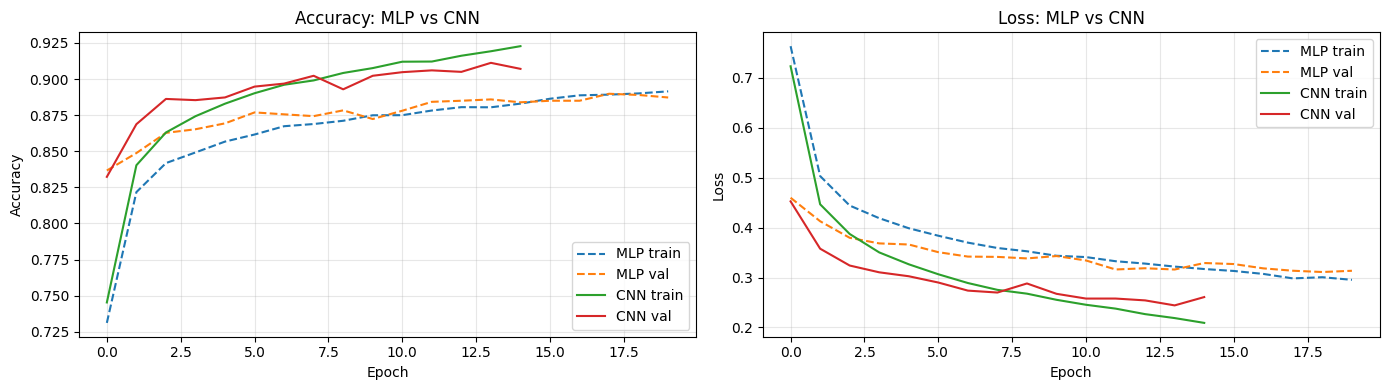

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mlp_history.history['accuracy'], '--', label='MLP train')
axes[0].plot(mlp_history.history['val_accuracy'], '--', label='MLP val')
axes[0].plot(cnn_history.history['accuracy'], label='CNN train')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: MLP vs CNN'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(mlp_history.history['loss'], '--', label='MLP train')
axes[1].plot(mlp_history.history['val_loss'], '--', label='MLP val')
axes[1].plot(cnn_history.history['loss'], label='CNN train')
axes[1].plot(cnn_history.history['val_loss'], label='CNN val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: MLP vs CNN'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Section 4: Visualize what the CNN learned

This is the wow moment. CNNs aren't black boxes if you look at them — you can SEE what each filter learned to detect.

First conv layer filters shape: (3, 3, 1, 32)


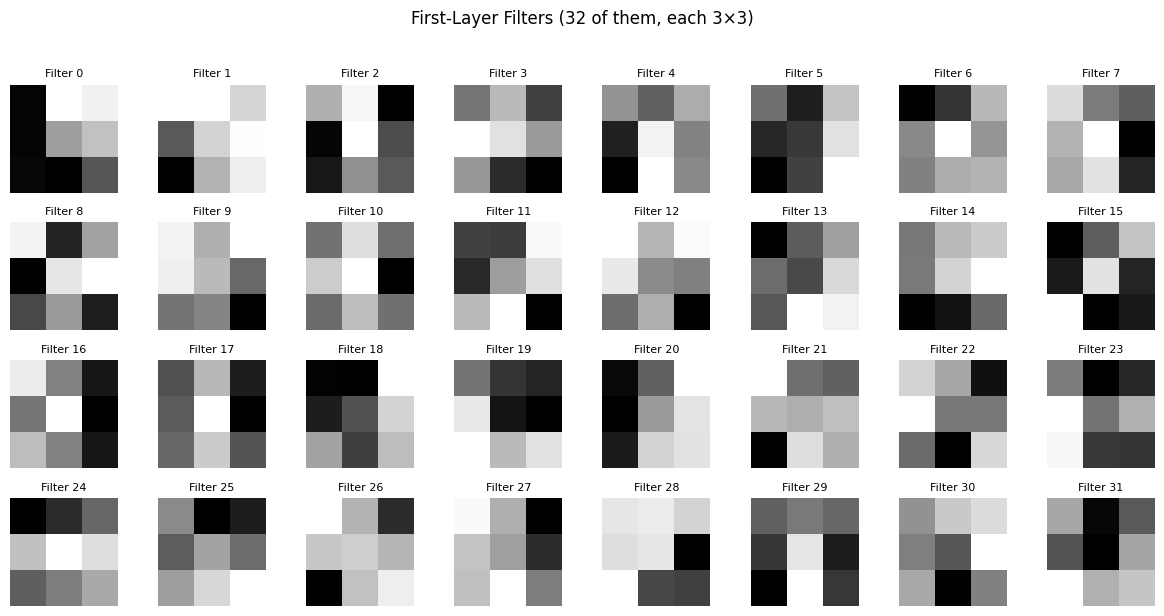


What do you see? Look for: edge detectors (light/dark transitions),
blob detectors, diagonal patterns. The network LEARNED these from data.


In [11]:
# Plot the learned filters from the FIRST conv layer
first_conv = cnn.layers[0]  # Conv2D(32, kernel_size=3)
filters, biases = first_conv.get_weights()
print(f'First conv layer filters shape: {filters.shape}')  # (3, 3, 1, 32)

# Normalize for visualization
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters_norm[:, :, 0, i], cmap='gray')
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('First-Layer Filters (32 of them, each 3×3)', y=1.02)
plt.tight_layout(); plt.show()
print('\nWhat do you see? Look for: edge detectors (light/dark transitions),')
print('blob detectors, diagonal patterns. The network LEARNED these from data.')

In [12]:
# Show feature maps for one test image — what each filter "saw"
sample_image = X_test[0:1]  # Shape (1, 28, 28, 1)
true_label = class_names[y_test[0]]

# Build a model that outputs intermediate activations
feature_extractor = keras.Model(
    inputs=cnn.inputs,
    outputs=[cnn.layers[0].output, cnn.layers[2].output]  # Both conv layers
)
conv1_features, conv2_features = feature_extractor.predict(sample_image, verbose=0)
print(f'Original image shape: {sample_image.shape}')
print(f'Conv1 feature maps shape: {conv1_features.shape}')
print(f'Conv2 feature maps shape: {conv2_features.shape}')

Original image shape: (1, 28, 28, 1)
Conv1 feature maps shape: (1, 28, 28, 32)
Conv2 feature maps shape: (1, 14, 14, 32)


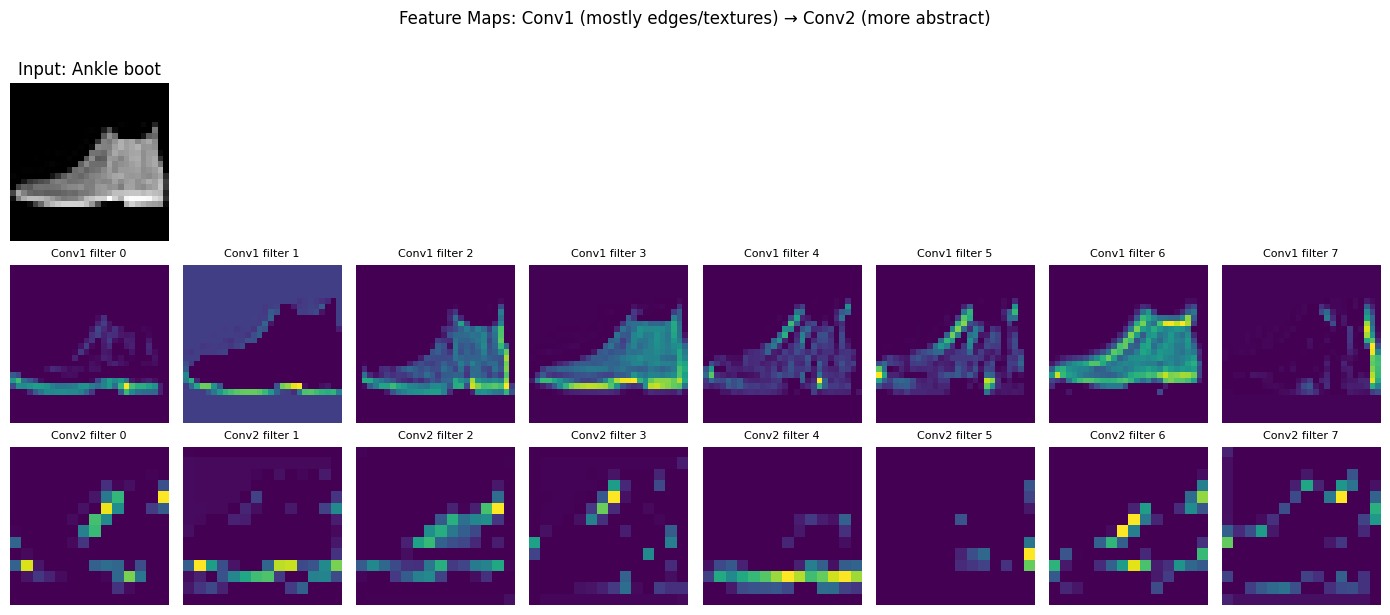

In [13]:
# Plot original image and a sample of feature maps
fig, axes = plt.subplots(3, 8, figsize=(14, 6))

# Row 0: Original image (only first cell used)
axes[0, 0].imshow(sample_image[0, :, :, 0], cmap='gray')
axes[0, 0].set_title(f'Input: {true_label}')
axes[0, 0].axis('off')
for j in range(1, 8):
    axes[0, j].axis('off')

# Row 1: Conv1 feature maps (first 8)
for j in range(8):
    axes[1, j].imshow(conv1_features[0, :, :, j], cmap='viridis')
    axes[1, j].set_title(f'Conv1 filter {j}', fontsize=8)
    axes[1, j].axis('off')

# Row 2: Conv2 feature maps (first 8)
for j in range(8):
    axes[2, j].imshow(conv2_features[0, :, :, j], cmap='viridis')
    axes[2, j].set_title(f'Conv2 filter {j}', fontsize=8)
    axes[2, j].axis('off')

plt.suptitle('Feature Maps: Conv1 (mostly edges/textures) → Conv2 (more abstract)', y=1.02)
plt.tight_layout(); plt.show()

**Key observation:** Conv1 features mostly highlight edges and local textures. Conv2 features look more abstract — they combine multiple Conv1 features into higher-level patterns. With more layers, this hierarchy continues: edges → textures → parts → objects.

This is the **"patterns of patterns"** principle. Each conv layer combines outputs of the previous layer into more complex detectors.

## Section 5: Inspect a misclassification

What does the CNN get wrong? Looking at mistakes builds intuition.

CNN got 915 of 10000 test examples wrong (9.15%)


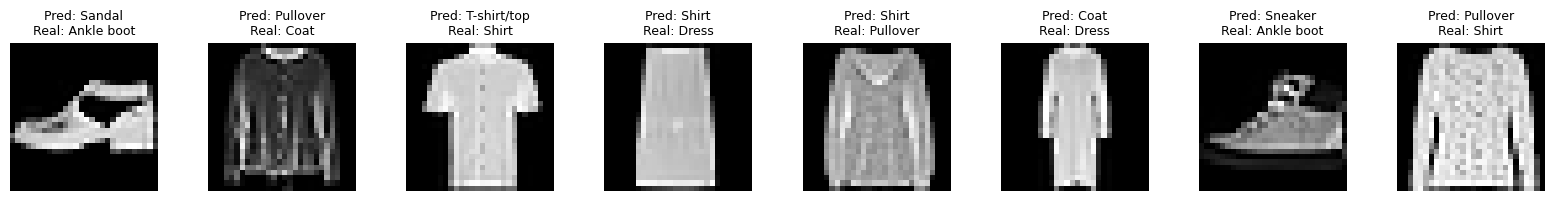

Common confusions: Shirt ↔ T-shirt, Pullover ↔ Coat — visually similar classes.


In [14]:
predictions = cnn.predict(X_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
wrong_indices = np.where(predicted_labels != y_test)[0]
print(f'CNN got {len(wrong_indices)} of {len(y_test)} test examples wrong ({len(wrong_indices)/len(y_test)*100:.2f}%)')

# Show 8 misclassifications
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    idx = wrong_indices[i]
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    pred = class_names[predicted_labels[idx]]
    actual = class_names[y_test[idx]]
    ax.set_title(f'Pred: {pred}\nReal: {actual}', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()
print('Common confusions: Shirt ↔ T-shirt, Pullover ↔ Coat — visually similar classes.')

## Section 6: Save the trained CNN

Same `model.save()` pattern from Week 7.

In [15]:
cnn.save('week8_fashion_mnist_cnn.keras')
print('Saved week8_fashion_mnist_cnn.keras')

# Verify load works
loaded = keras.models.load_model('week8_fashion_mnist_cnn.keras')
loaded_acc = loaded.evaluate(X_test, y_test, verbose=0)[1]
print(f'Loaded model test accuracy: {loaded_acc:.4f}')

Saved week8_fashion_mnist_cnn.keras


Loaded model test accuracy: 0.9085


## Wrap-up: what you did today

1. **Built a CNN** with `Conv2D + MaxPooling2D + Flatten + Dense` — a fundamentally different architecture for spatial data
2. **Beat the Week 7 MLP baseline** — same task, better accuracy, matched parameter count
3. **Saw what filters learned** — edge/blob detectors emerging from random initialization through training
4. **Visualized feature map hierarchies** — shallow layers detect simple patterns, deeper layers detect more abstract patterns

## Looking ahead: Week 9
Today you trained on 60,000 labeled images. **What if you only have 200?** Training from scratch wouldn't work — there's not enough data to learn useful features. But you can take a model that someone ALREADY trained on millions of images, and adapt it to your data. That's transfer learning.

## Post-class assignment
Next: open `week8_pair_programming.ipynb` to try architecture variants, or jump to `week8_postclass_exercise.ipynb` for the CIFAR-10 (color images) exercise.